# Open recordings and verify quality and coverage

In [89]:
import sys
import os
import time
import datetime as dt
import math
import numpy as np 
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json 
import heartpy as hp

from scipy.signal import butter, filtfilt, argrelextrema
from scipy import interpolate
from scipy.interpolate import interp1d

In [12]:
%load_ext autoreload
%autoreload 1
%aimport qex
%aimport rp2
%aimport mh

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [92]:
 %reload_ext autoreload

In [261]:
def rmssd(ibi_list):
    ibi_list = pd.Series(ibi_list)
    ms = np.sqrt(ibi_list.diff().pow(2).sum()/(len(ibi_list)-1))
    return ms

def HR_avg(ibi_list):
    ibi_list = pd.Series(ibi_list)
    bpm = 60000/ibi_list.mean()
    return bpm

## load example data

In [80]:
Timing_file = pd.read_csv('../Timing/Onset times session 1.1.csv',skiprows=5)
Timing_file.loc[:,'Times'] = pd.to_datetime('April 4th, 2023, ' + Timing_file.loc[:,'Times'])
Timing_file.loc[:,'Times.1'] = pd.to_datetime('April 4th, 2023, ' + Timing_file.loc[:,'Times.1'])

In [78]:
data_loc = '../Equivitals/'
eqfiles = qex.qiosk_rec_check(data_loc,'','/')
eqfiles = qex.remove_tz_from_dataframe(eqfiles)

In [79]:
eqfiles

,Signal,DevName,ID,Date,Session,FileName,FileType,FileSize,RecStart,RecEnd,...,SubjectNames,SENSOR ID,SUBJECT ID,SUBJECT AGE,HR(BPM),HRC(%),BELT OFF,LEAD OFF,MOTION,BODY POSITION
0,DATA,BLUETOOTH02,5022285,231005,101,DATA-BLUETOOTH02-5022285-23100500_0.CSV,csv,24903,2023-10-05 12:00:40,2023-10-05 13:08:10,...,[BLUETOOTH02],5022285.0,BLUETOOTH02,53.0,83,97.0,0.0,0.0,Stationary,Upright
1,DATA,BLUETOOTH01,5022281,231005,101,DATA-BLUETOOTH01-5022281-23100500_0.CSV,csv,23560,2023-10-05 12:02:19,2023-10-05 13:06:19,...,[BLUETOOTH01],5022281.0,BLUETOOTH01,53.0,83,97.0,0.0,0.0,Stationary,Upright
2,DATA,VA308,5022131,231012,101,DATA-VA308-5022131-23101200_0.CSV,csv,21514,2023-10-12 11:03:36,2023-10-12 12:06:06,...,[VA308],5022131.0,VA308,53.0,88,98.0,0.0,0.0,Stationary,Upright
3,DATA,VA307,5022127,231012,101,DATA-VA307-5022127-23101200_0.CSV,csv,21264,2023-10-12 11:05:21,2023-10-12 12:07:06,...,[VA307],5022127.0,VA307,53.0,85,97.0,0.0,0.0,Stationary,Upright
4,DATA,BLUETOOTH02,5022285,240402,0,DATA-BLUETOOTH02-5022285-24040200.CSV,csv,27639,2024-04-02 11:54:11,2024-04-02 13:09:11,...,[BLUETOOTH02],5022285.0,BLUETOOTH02,53.0,79,98.0,0.0,0.0,Stationary,Upright
5,DATA,BLUETOOTH01,5022281,240402,0,DATA-BLUETOOTH01-5022281-24040200.CSV,csv,27556,2024-04-02 11:54:41,2024-04-02 13:09:41,...,[BLUETOOTH01],5022281.0,BLUETOOTH01,53.0,83,97.0,0.0,0.0,Stationary,Upright
6,DATA,BLUETOOTH02,5022285,240410,0,DATA-BLUETOOTH02-5022285-24041000.CSV,csv,27261,2024-04-10 10:48:28,2024-04-10 12:02:28,...,[BLUETOOTH02],5022285.0,BLUETOOTH02,53.0,81,98.0,0.0,0.0,Stationary,Upright
7,DATA,BLUETOOTH01,5022281,240410,0,DATA-BLUETOOTH01-5022281-24041000.CSV,csv,27337,2024-04-10 10:49:06,2024-04-10 12:03:21,...,[BLUETOOTH01],5022281.0,BLUETOOTH01,53.0,89,97.0,0.0,0.0,Stationary,Upright
8,DATA,BLUETOOTH02,5022285,240417,101,DATA-BLUETOOTH02-5022285-24041700_0.CSV,csv,29048,2024-04-17 10:14:41,2024-04-17 11:33:57,...,[BLUETOOTH02],5022285.0,BLUETOOTH02,53.0,79,98.0,0.0,0.0,Stationary,Upright
9,DATA,BLUETOOTH01,5022281,240417,101,DATA-BLUETOOTH01-5022281-24041700_0.CSV,csv,29785,2024-04-17 10:15:01,2024-04-17 11:36:16,...,[BLUETOOTH01],5022281.0,BLUETOOTH01,53.0,90,97.0,0.0,0.0,Stationary,Upright


It seems we don't have the correct physiologial measurement files, dating 23 oct and 24 april, not May (24) and June 2023 (7, 14, 21, 28).


Below I've constructed the evaluation process, which should be easily ammended to evaluate the correct files.

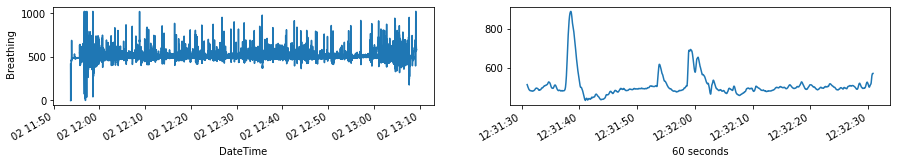

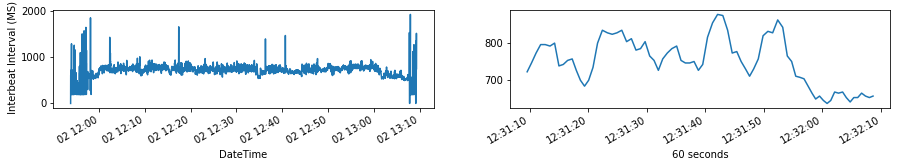

In [87]:
sig_tags = ['RESPloc', 'RRloc'] # 'ACCloc', 'DATAloc', , 'ECGloc'
recindex = 4
for sig_file in sig_tags:
    V=pd.read_csv(eqfiles.loc[recindex,sig_file])
    qex.test_plot_signals(V)

In [84]:
# Session 4,5, 2024-04-02 11:54:11+00:00, aligned at 12:10? 
timing_adjustment = eqfiles.loc[recindex,'RecStart'] - Timing_file.loc[0,'Times'] + pd.to_timedelta(600,unit='s')

[Timestamp('2024-04-02 12:04:11'), Timestamp('2024-04-02 12:05:11')]


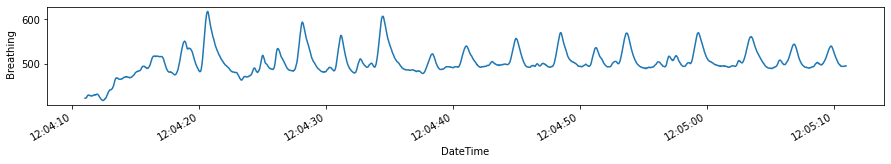

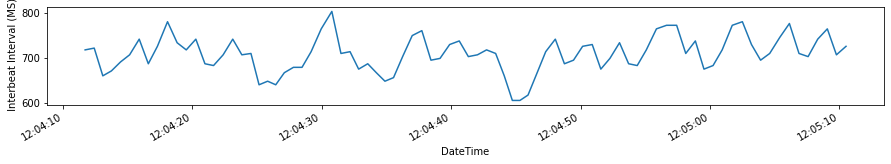

In [95]:
sig_tags = ['RESPloc', 'RRloc'] # 'ACCloc', 'DATAloc', , 'ECGloc'
recindex = 5

t1 = Timing_file.loc[0,'Times'] + timing_adjustment 
t2 = Timing_file.loc[0,'Times'] + pd.to_timedelta(60,unit='s') + timing_adjustment 
print([t1,t2])
for sig_file in sig_tags:
    V=pd.read_csv(eqfiles.loc[recindex,sig_file])
    V['DateTime'] = pd.to_datetime(V['DateTime'])
    V = qex.remove_tz_from_dataframe(V)
    qex.test_plot_signals_interval(V,t1,t2)

### cardiac cleaning

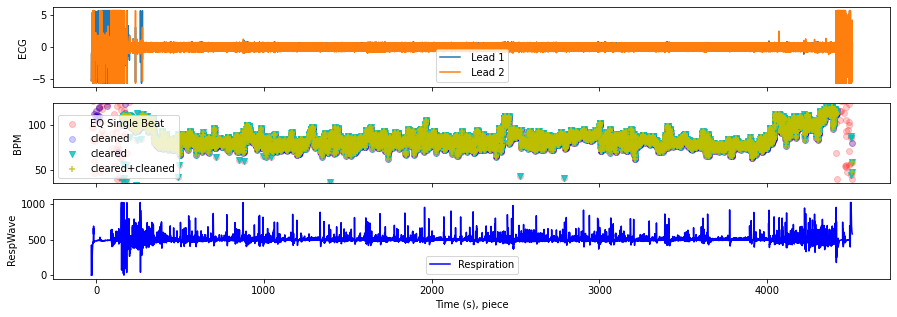

In [263]:
recindex = 4
V = pd.read_csv(eqfiles.loc[recindex,'RRloc']) 
V['DateTime'] = pd.to_datetime(V['DateTime'])
V = qex.remove_tz_from_dataframe(V)
V['c_sTime'] = (V['DateTime']-eqfiles.loc[recindex,'RecStart']).dt.total_seconds()
sig_t = V['c_sTime']
sig_v = V[' Interbeat Interval (MS)']

C = pd.read_csv(eqfiles.loc[recindex,'ECGloc'])
C['DateTime'] = pd.to_datetime(C['DateTime'])
C = qex.remove_tz_from_dataframe(C)
C['c_sTime'] = (C['DateTime']-eqfiles.loc[recindex,'RecStart']).dt.total_seconds()
R = pd.read_csv(eqfiles.loc[recindex,'RESPloc'])
R['DateTime'] = pd.to_datetime(R['DateTime'])
R = qex.remove_tz_from_dataframe(R)
R['c_sTime'] = (R['DateTime']-eqfiles.loc[recindex,'RecStart']).dt.total_seconds()

atype='default'
IBI=mh.clean_IBI(sig_t,sig_v,activitytype=atype)
newIBI = mh.contact_noise_cut(C['c_sTime'],C[' Lead 1'],V['c_sTime'],V[' Interbeat Interval (MS)'],0.25)
newV = V.loc[newIBI.index,:]
newIBI = mh.contact_noise_cut(C['c_sTime'],C[' Lead 2'],newV['c_sTime'],newV[' Interbeat Interval (MS)'],0.25)
newV = newV.loc[newIBI.index,:]
newIBI=mh.clean_IBI(newV['c_sTime'],newV[' Interbeat Interval (MS)'],activitytype=atype)

Respwave = R.query('c_sTime>500').copy()
Respwave.set_index('c_sTime',drop=True,inplace=True)
Breaths = rp2.breath_cycles(rp2.EQ_Inspiration_Extract(Respwave.loc[:,' Breathing']),Respwave.loc[:,' Breathing'])

fig, (ax) = plt.subplots(3, 1,figsize = [15,5],sharex = True)
ax[1].scatter(x =sig_t,y=(60000/sig_v),color='r',alpha = 0.2,label='EQ Single Beat')
ax[1].scatter(x = IBI.index,y = (60000/IBI['IBI']),color='b',alpha = 0.2,label='cleaned')
ax[1].scatter(x =newV['c_sTime'],y=(60000/newV[' Interbeat Interval (MS)']),color='c',marker = 'v',alpha = 0.8,label='cleared')
ax[1].scatter(x = newIBI.index,y = (60000/newIBI['IBI']),color='y',marker = '+',alpha = 0.8,label='cleared+cleaned')

ax[1].set(ylabel='BPM',ylim=[35,125])
ax[0].plot(C['c_sTime'],C[[' Lead 1',' Lead 2']],label=[' Lead 1',' Lead 2'])
# ax[0].plot(Calt['c_sTime'],Calt[['Lead 1','Lead 2']],label=['altLead 1','altLead 2'])

ax[0].set_ylabel('ECG')
ax[2].plot(R['c_sTime'],R[' Breathing'],color = 'b',label='Respiration')
ax[2].set_xlabel('Time (s), piece')
ax[2].set_ylabel('RespWave')
ax[0].legend()
ax[1].legend()

ax[2].legend()
# ax[0].set_title(partID +' '+ Event+' EGC, device derived IBI, and Respiration')
plt.show()

In [285]:
t=Timing_file.loc[16,'Times'] #17
    # needs to be corrected when the files have the right correspondence    
cht = (t-Timing_file.loc[0,'Times']).total_seconds()
chx = cht+t_int
    

Ex = newIBI.query('time>@cht and time<@chx').copy()
Ex['IBI'].notna().sum()

86

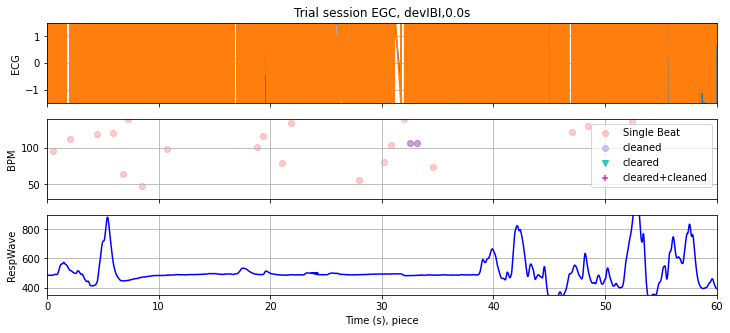

{'Start Time': '2023/04/04 08:32:44', 'Recording': 5, 'Initial Beat Count': 214, 'Cleaned Beat Count': 0, 'Avg HR': nan, 'RMSSD': -0.0, 'Breath Count': 0, 'Avg BR': nan, 'Avg IE ratio': nan, 'Seq Var': nan}


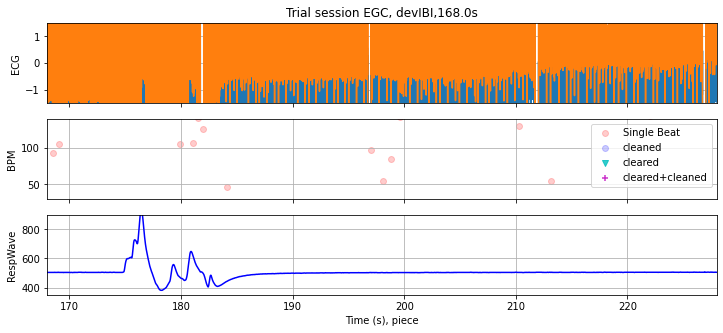

{'Start Time': '2023/04/04 08:35:32', 'Recording': 5, 'Initial Beat Count': 177, 'Cleaned Beat Count': 0, 'Avg HR': nan, 'RMSSD': -0.0, 'Breath Count': 0, 'Avg BR': nan, 'Avg IE ratio': nan, 'Seq Var': nan}


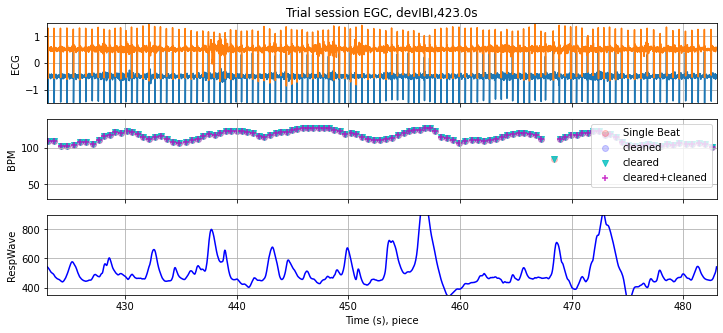

{'Start Time': '2023/04/04 08:39:47', 'Recording': 5, 'Initial Beat Count': 115, 'Cleaned Beat Count': 113, 'Avg HR': 115.2708354585331, 'RMSSD': 12.296412256669216, 'Breath Count': 0, 'Avg BR': nan, 'Avg IE ratio': nan, 'Seq Var': nan}


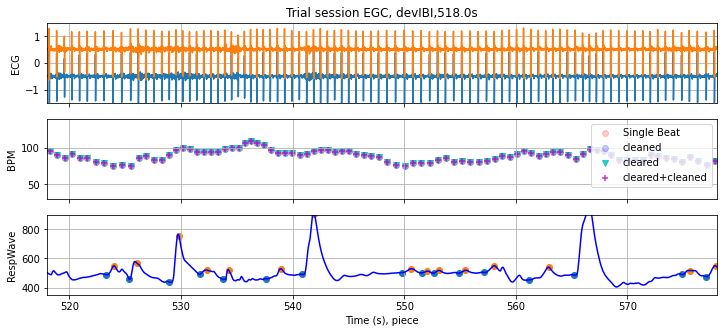

{'Start Time': '2023/04/04 08:41:22', 'Recording': 5, 'Initial Beat Count': 89, 'Cleaned Beat Count': 89, 'Avg HR': 88.73674764864236, 'RMSSD': 30.934314574301112, 'Breath Count': 16, 'Avg BR': 23.629879062111463, 'Avg IE ratio': 0.467339453716053, 'Seq Var': 1.8351789751030048}


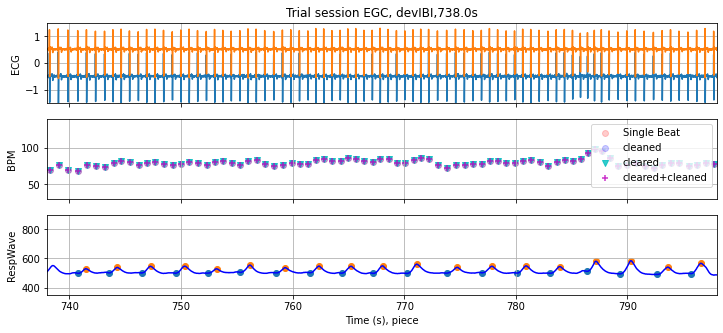

{'Start Time': '2023/04/04 08:45:02', 'Recording': 5, 'Initial Beat Count': 80, 'Cleaned Beat Count': 80, 'Avg HR': 79.5452662280629, 'RMSSD': 36.2390096827274, 'Breath Count': 19, 'Avg BR': 19.860702070537105, 'Avg IE ratio': 0.3903300644201363, 'Seq Var': 1.0750543460948017}


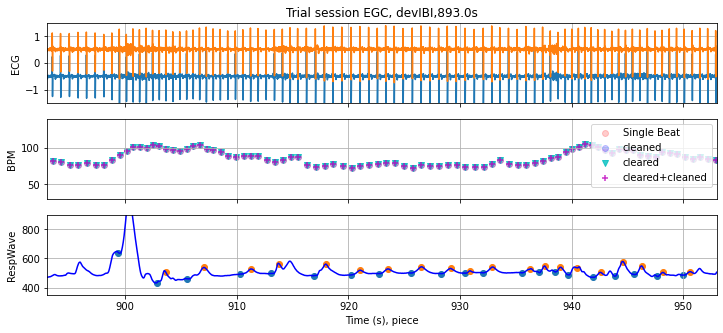

{'Start Time': '2023/04/04 08:47:37', 'Recording': 5, 'Initial Beat Count': 86, 'Cleaned Beat Count': 86, 'Avg HR': 85.8169238956892, 'RMSSD': 28.247227870234294, 'Breath Count': 21, 'Avg BR': 26.52779239335185, 'Avg IE ratio': 0.5059930346206246, 'Seq Var': 1.33617530941071}


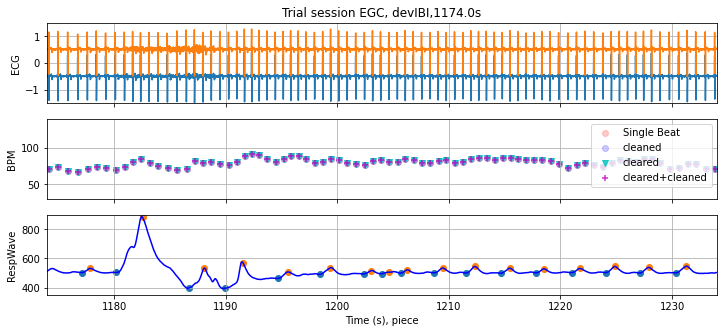

{'Start Time': '2023/04/04 08:52:18', 'Recording': 5, 'Initial Beat Count': 80, 'Cleaned Beat Count': 80, 'Avg HR': 79.39133311280185, 'RMSSD': 37.50510513773298, 'Breath Count': 17, 'Avg BR': 19.796430014918997, 'Avg IE ratio': 0.4149739289425338, 'Seq Var': 1.2700468553705375}


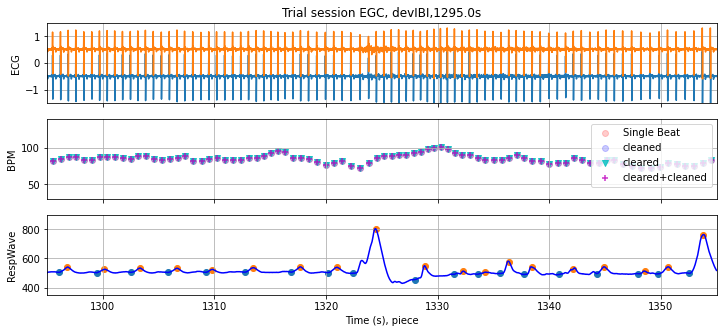

{'Start Time': '2023/04/04 08:54:19', 'Recording': 5, 'Initial Beat Count': 84, 'Cleaned Beat Count': 84, 'Avg HR': 84.51837939361417, 'RMSSD': 27.707595409444934, 'Breath Count': 19, 'Avg BR': 19.88077011744201, 'Avg IE ratio': 0.38607105697140326, 'Seq Var': 1.405332125652185}


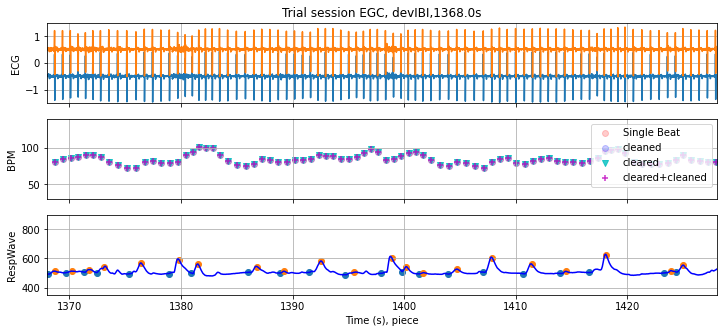

{'Start Time': '2023/04/04 08:55:32', 'Recording': 5, 'Initial Beat Count': 84, 'Cleaned Beat Count': 84, 'Avg HR': 84.10793852110208, 'RMSSD': 37.27753288284145, 'Breath Count': 21, 'Avg BR': 26.280723767550334, 'Avg IE ratio': 0.46388733026090484, 'Seq Var': 1.5970568194952468}


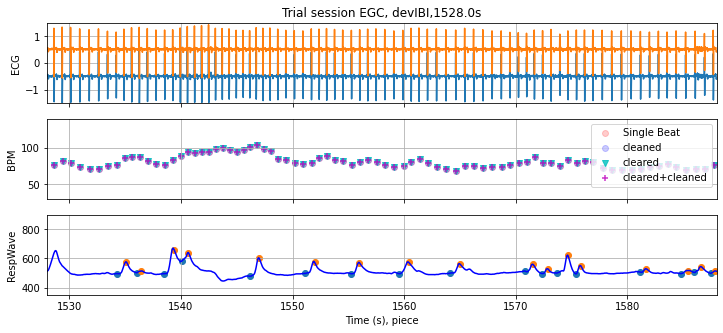

{'Start Time': '2023/04/04 08:58:12', 'Recording': 5, 'Initial Beat Count': 80, 'Cleaned Beat Count': 80, 'Avg HR': 80.24877119069114, 'RMSSD': 37.20759416155712, 'Breath Count': 17, 'Avg BR': 24.402892003828025, 'Avg IE ratio': 0.4957148103911636, 'Seq Var': 1.7573152498255706}


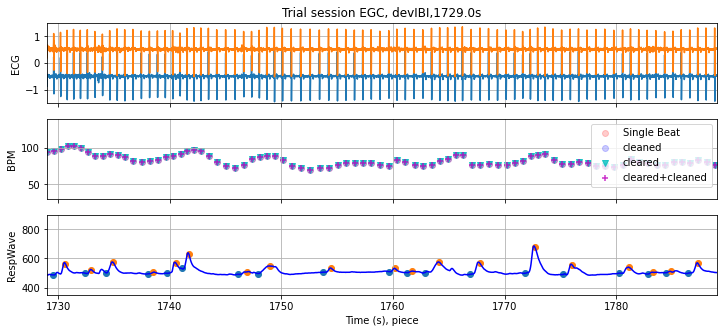

{'Start Time': '2023/04/04 09:01:33', 'Recording': 5, 'Initial Beat Count': 83, 'Cleaned Beat Count': 83, 'Avg HR': 82.38894863098685, 'RMSSD': 35.77487195525141, 'Breath Count': 19, 'Avg BR': 23.939873918596202, 'Avg IE ratio': 0.4170891806393243, 'Seq Var': 1.826556953145314}


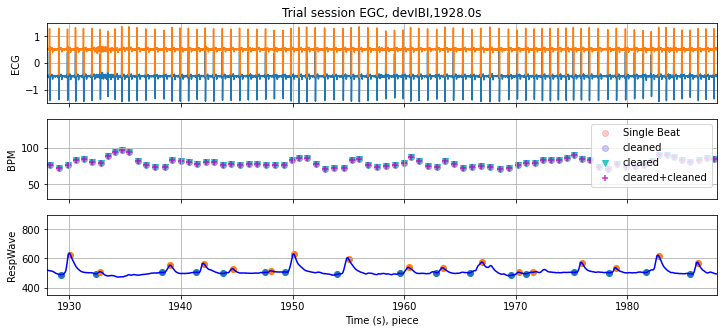

{'Start Time': '2023/04/04 09:04:52', 'Recording': 5, 'Initial Beat Count': 80, 'Cleaned Beat Count': 80, 'Avg HR': 79.63104283486513, 'RMSSD': 41.47273009788663, 'Breath Count': 17, 'Avg BR': 19.40892394189103, 'Avg IE ratio': 0.34268718771732387, 'Seq Var': 1.5886754464580544}


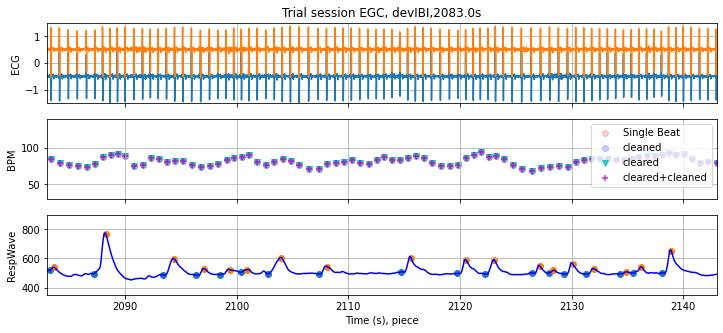

{'Start Time': '2023/04/04 09:07:27', 'Recording': 5, 'Initial Beat Count': 82, 'Cleaned Beat Count': 82, 'Avg HR': 81.63400753289419, 'RMSSD': 39.3654921893356, 'Breath Count': 18, 'Avg BR': 23.22581638615939, 'Avg IE ratio': 0.40996520579168655, 'Seq Var': 1.746856086149702}


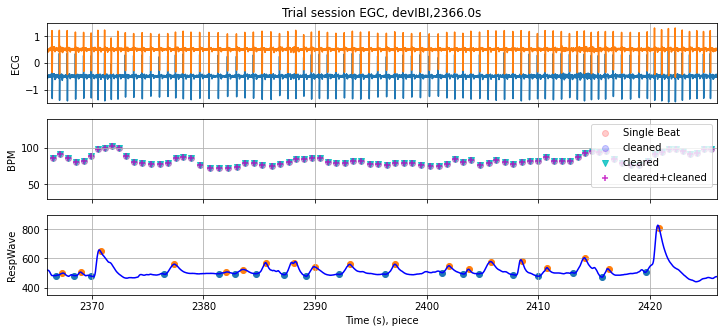

{'Start Time': '2023/04/04 09:12:10', 'Recording': 5, 'Initial Beat Count': 83, 'Cleaned Beat Count': 83, 'Avg HR': 83.5010060362173, 'RMSSD': 33.767497722499726, 'Breath Count': 19, 'Avg BR': 24.0890627433688, 'Avg IE ratio': 0.4514514810965204, 'Seq Var': 1.6288116233215826}


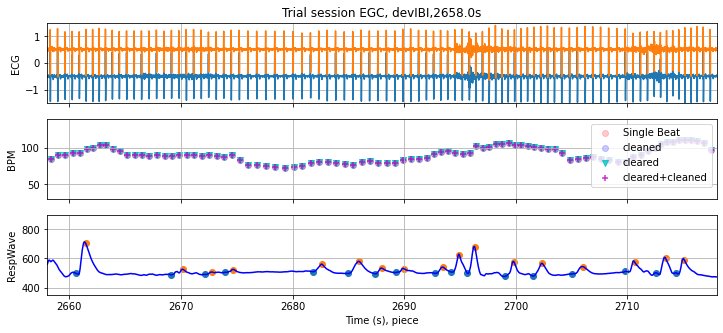

{'Start Time': '2023/04/04 09:17:02', 'Recording': 5, 'Initial Beat Count': 90, 'Cleaned Beat Count': 90, 'Avg HR': 90.29194395211184, 'RMSSD': 23.165986302083375, 'Breath Count': 17, 'Avg BR': 22.506696431018696, 'Avg IE ratio': 0.46242980144400714, 'Seq Var': 1.82456925856582}


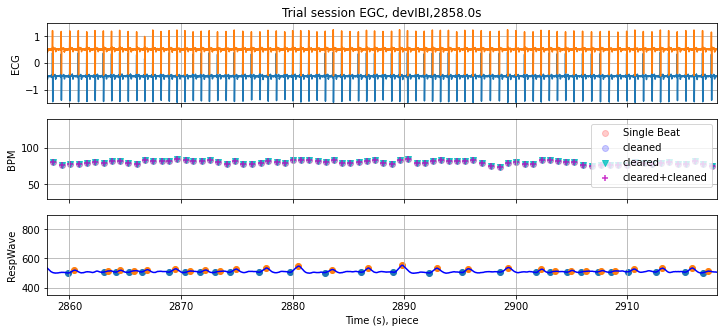

{'Start Time': '2023/04/04 09:20:22', 'Recording': 5, 'Initial Beat Count': 80, 'Cleaned Beat Count': 80, 'Avg HR': 80.34548558802852, 'RMSSD': 22.906524414661725, 'Breath Count': 28, 'Avg BR': 33.93925869621732, 'Avg IE ratio': 0.41144211585501983, 'Seq Var': 1.3033070281183772}


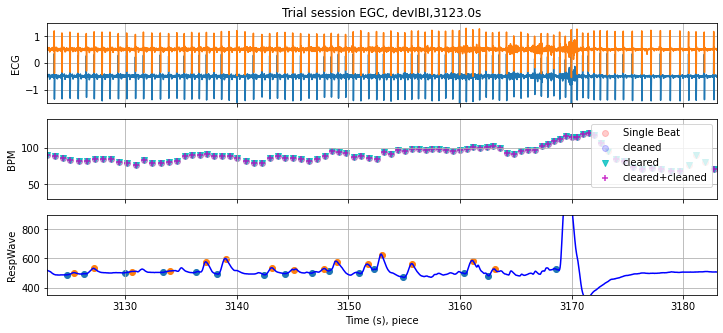

{'Start Time': '2023/04/04 09:24:47', 'Recording': 5, 'Initial Beat Count': 90, 'Cleaned Beat Count': 86, 'Avg HR': 89.6020004167535, 'RMSSD': 24.827494726251025, 'Breath Count': 16, 'Avg BR': 23.542666876772934, 'Avg IE ratio': 0.5658821773950279, 'Seq Var': 1.8636206764632401}


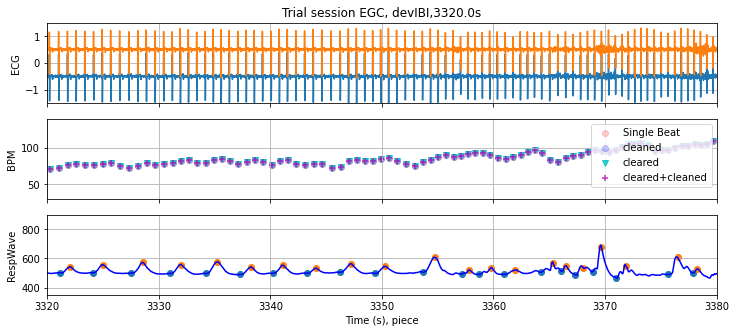

{'Start Time': '2023/04/04 09:28:04', 'Recording': 5, 'Initial Beat Count': 86, 'Cleaned Beat Count': 86, 'Avg HR': 85.63320444097782, 'RMSSD': 27.71642112539063, 'Breath Count': 21, 'Avg BR': 23.245519752574715, 'Avg IE ratio': 0.5204426132310671, 'Seq Var': 1.3804097275192135}


,Start Time,Recording,Initial Beat Count,Cleaned Beat Count,Avg HR,RMSSD,Breath Count,Avg BR,Avg IE ratio,Seq Var
5 2023/04/04 08:32:44,2023/04/04 08:32:44,5,214,0,NaN,-0.0,0,NaN,NaN,NaN
5 2023/04/04 08:35:32,2023/04/04 08:35:32,5,177,0,NaN,-0.0,0,NaN,NaN,NaN
5 2023/04/04 08:39:47,2023/04/04 08:39:47,5,115,113,115.270835,12.296412,0,NaN,NaN,NaN
5 2023/04/04 08:41:22,2023/04/04 08:41:22,5,89,89,88.736748,30.934315,16,23.629879,0.467339,1.835179
5 2023/04/04 08:45:02,2023/04/04 08:45:02,5,80,80,79.545266,36.23901,19,19.860702,0.39033,1.075054
5 2023/04/04 08:47:37,2023/04/04 08:47:37,5,86,86,85.816924,28.247228,21,26.527792,0.505993,1.336175
5 2023/04/04 08:52:18,2023/04/04 08:52:18,5,80,80,79.391333,37.505105,17,19.79643,0.414974,1.270047
5 2023/04/04 08:54:19,2023/04/04 08:54:19,5,84,84,84.518379,27.707595,19,19.88077,0.386071,1.405332
5 2023/04/04 08:55:32,2023/04/04 08:55:32,5,84,84,84.107939,37.277533,21,26.280724,0.463887,1.597057
5 2023/04/04 08:58:12,2023/04/04 08:58:12,5,80,80,80.248771,37.207594,17,24.402892,0.495715,1.757315


In [286]:
t_int =60
sig_ex = 'Trial session'
session_stats = {}
for t in Timing_file.loc[:17,'Times']: #17
    # needs to be corrected when the files have the right correspondence    
    cht = (t-Timing_file.loc[0,'Times']).total_seconds()
    chx = cht+t_int
    
    interval_stats = {}
    interval_stats['Start Time'] = t.strftime('%Y/%m/%d %H:%M:%S')
    interval_stats['Recording'] = recindex
    
    fig, (ax) = plt.subplots(3, 1,figsize = [12,5],sharex = True)
    Ex = C.query('c_sTime>@cht and c_sTime<@chx').copy()
    ax[0].plot(Ex['c_sTime'],Ex[' Lead 1']-0.5)
    ax[0].plot(Ex['c_sTime'],Ex[' Lead 2']+0.5)
    ax[0].set_ylabel('ECG')
    ax[0].set_title(sig_ex +' EGC, devIBI,' + str(cht)+'s')
    ax[0].set_xlim([cht,chx])
    ax[0].set_ylim([-1.5,1.5])
    Ex = V.query('c_sTime>@cht and c_sTime<@chx').copy()
    interval_stats['Initial Beat Count'] = len(Ex)

    ax[1].scatter(x =Ex['c_sTime'],y=(60000/Ex[' Interbeat Interval (MS)']),color='r',alpha = 0.2,label='Single Beat')
    Ex = IBI.query('time>@cht and time<@chx').copy()
    ax[1].scatter(x = Ex.index,y = (60000/Ex['IBI']),color='b',alpha = 0.2,label='cleaned')
    Ex = newV.query('c_sTime>@cht and c_sTime<@chx').copy()
    ax[1].scatter(x =Ex['c_sTime'],y=(60000/Ex[' Interbeat Interval (MS)']),color='c',marker = 'v',alpha = 0.8,label='cleared')
    Ex = newIBI.query('time>@cht and time<@chx').copy()
    interval_stats['Cleaned Beat Count'] =Ex['IBI'].notna().sum()
    ax[1].scatter(x = Ex.index,y = (60000/Ex['IBI']),color='m',marker = '+',alpha = 0.8,label='cleared+cleaned')
    ax[1].legend(loc='upper right')
    ax[1].set_ylabel('BPM')
    ax[1].set_ylim([30,140])
    interval_stats['Avg HR'] = HR_avg(Ex['IBI'])
    interval_stats['RMSSD'] =rmssd(Ex['IBI'])


    Ex = R.query('c_sTime>@cht and c_sTime<@chx').copy()
    ax[2].plot(Ex['c_sTime'],Ex[' Breathing'],color = 'b',label='Respiration')
    Ex = Breaths.query('In>@cht and Ex<@chx').copy()
    ax[2].scatter(Ex['In'],Ex['In_C'])
    ax[2].scatter(Ex['Ex'],Ex['Ex_C'])
    ax[2].set_xlabel('Time (s), piece')
    ax[2].set_ylabel('RespWave')
    ax[2].set_ylim([350,900])

    interval_stats['Breath Count'] = len(Ex)
    interval_stats['Avg BR'] =(60/Ex['Period_T']).mean()
    interval_stats['Avg IE ratio'] =(Ex['IE_Ratio']).mean()
    interval_stats['Seq Var'] =np.power(10,np.log10((Ex['Period_T']/Ex['Period_T'].shift(-1))).abs().mean())
    ax[2].grid()
    ax[1].grid()
    ax[0].grid()
    plt.show()
    print(interval_stats)
    session_stats[' '.join([str(recindex),t.strftime('%Y/%m/%d %H:%M:%S')])] = interval_stats
#     plt.savefig(plot_loc+'_'.join([sig_ex,'Cardio',str(cht)+'s'])+'.png',dpi=mydpi)
    plt.show()
    
Evaluated_Intervals =pd.DataFrame(data=session_stats).transpose()
Evaluated_Intervals 

Clipped!


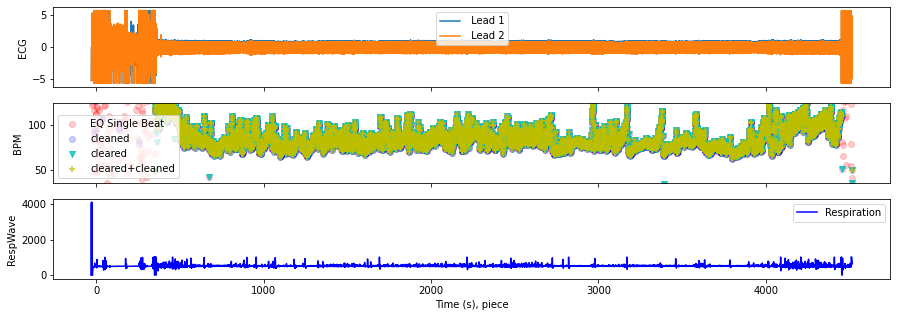

In [287]:
recindex = 5
V = pd.read_csv(eqfiles.loc[recindex,'RRloc']) 
V['DateTime'] = pd.to_datetime(V['DateTime'])
V = qex.remove_tz_from_dataframe(V)
V['c_sTime'] = (V['DateTime']-eqfiles.loc[recindex,'RecStart']).dt.total_seconds()
sig_t = V['c_sTime']
sig_v = V[' Interbeat Interval (MS)']

C = pd.read_csv(eqfiles.loc[recindex,'ECGloc'])
C['DateTime'] = pd.to_datetime(C['DateTime'])
C = qex.remove_tz_from_dataframe(C)
C['c_sTime'] = (C['DateTime']-eqfiles.loc[recindex,'RecStart']).dt.total_seconds()
R = pd.read_csv(eqfiles.loc[recindex,'RESPloc'])
R['DateTime'] = pd.to_datetime(R['DateTime'])
R = qex.remove_tz_from_dataframe(R)
R['c_sTime'] = (R['DateTime']-eqfiles.loc[recindex,'RecStart']).dt.total_seconds()

atype='default'
IBI=mh.clean_IBI(sig_t,sig_v,activitytype=atype)
newIBI = mh.contact_noise_cut(C['c_sTime'],C[' Lead 1'],V['c_sTime'],V[' Interbeat Interval (MS)'],0.25)
newV = V.loc[newIBI.index,:]
newIBI = mh.contact_noise_cut(C['c_sTime'],C[' Lead 2'],newV['c_sTime'],newV[' Interbeat Interval (MS)'],0.25)
newV = newV.loc[newIBI.index,:]
newIBI=mh.clean_IBI(newV['c_sTime'],newV[' Interbeat Interval (MS)'],activitytype=atype)

Respwave = R.query('c_sTime>500').copy()
Respwave.set_index('c_sTime',drop=True,inplace=True)
Breaths = rp2.breath_cycles(rp2.EQ_Inspiration_Extract(Respwave.loc[:,' Breathing']),Respwave.loc[:,' Breathing'])

fig, (ax) = plt.subplots(3, 1,figsize = [15,5],sharex = True)
ax[1].scatter(x =sig_t,y=(60000/sig_v),color='r',alpha = 0.2,label='EQ Single Beat')
ax[1].scatter(x = IBI.index,y = (60000/IBI['IBI']),color='b',alpha = 0.2,label='cleaned')
ax[1].scatter(x =newV['c_sTime'],y=(60000/newV[' Interbeat Interval (MS)']),color='c',marker = 'v',alpha = 0.8,label='cleared')
ax[1].scatter(x = newIBI.index,y = (60000/newIBI['IBI']),color='y',marker = '+',alpha = 0.8,label='cleared+cleaned')

ax[1].set(ylabel='BPM',ylim=[35,125])
ax[0].plot(C['c_sTime'],C[[' Lead 1',' Lead 2']],label=[' Lead 1',' Lead 2'])
# ax[0].plot(Calt['c_sTime'],Calt[['Lead 1','Lead 2']],label=['altLead 1','altLead 2'])

ax[0].set_ylabel('ECG')
ax[2].plot(R['c_sTime'],R[' Breathing'],color = 'b',label='Respiration')
ax[2].set_xlabel('Time (s), piece')
ax[2].set_ylabel('RespWave')
ax[0].legend()
ax[1].legend()

ax[2].legend()
# ax[0].set_title(partID +' '+ Event+' EGC, device derived IBI, and Respiration')
plt.show()

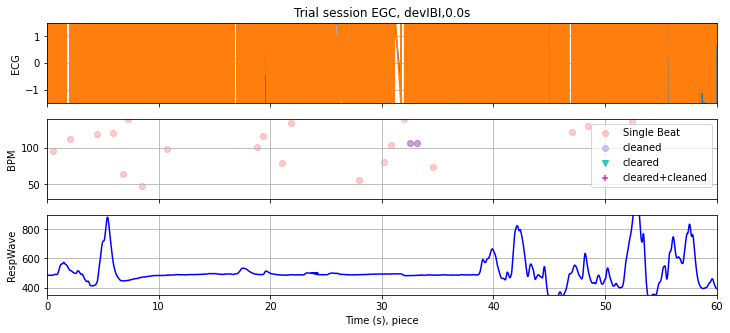

{'Start Time': '2023/04/04 08:32:44', 'Recording': 5, 'Initial Beat Count': 214, 'Cleaned Beat Count': 0, 'Avg HR': nan, 'RMSSD': -0.0, 'Breath Count': 0, 'Avg BR': nan, 'Avg IE ratio': nan, 'Seq Var': nan}


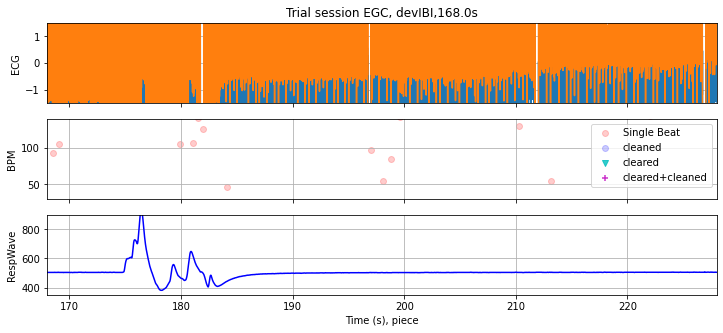

{'Start Time': '2023/04/04 08:35:32', 'Recording': 5, 'Initial Beat Count': 177, 'Cleaned Beat Count': 0, 'Avg HR': nan, 'RMSSD': -0.0, 'Breath Count': 0, 'Avg BR': nan, 'Avg IE ratio': nan, 'Seq Var': nan}


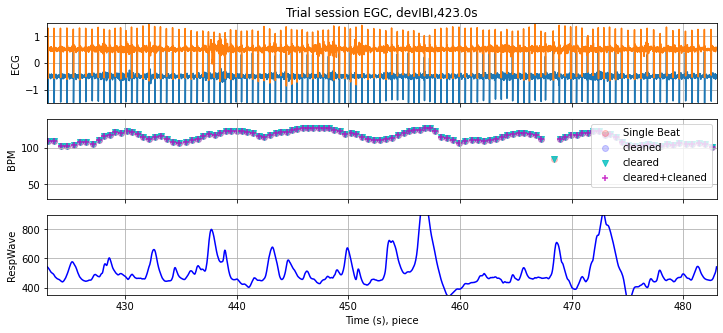

{'Start Time': '2023/04/04 08:39:47', 'Recording': 5, 'Initial Beat Count': 115, 'Cleaned Beat Count': 113, 'Avg HR': 115.2708354585331, 'RMSSD': 12.296412256669216, 'Breath Count': 0, 'Avg BR': nan, 'Avg IE ratio': nan, 'Seq Var': nan}


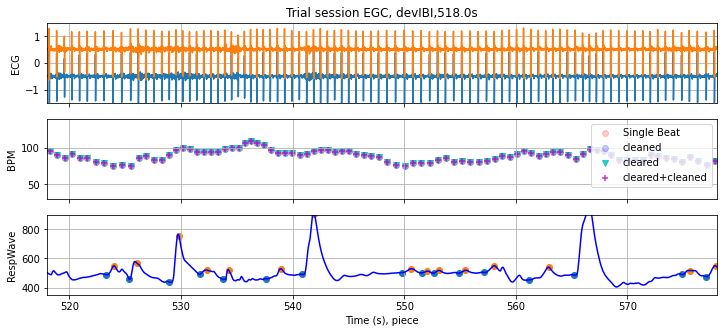

{'Start Time': '2023/04/04 08:41:22', 'Recording': 5, 'Initial Beat Count': 89, 'Cleaned Beat Count': 89, 'Avg HR': 88.73674764864236, 'RMSSD': 30.934314574301112, 'Breath Count': 16, 'Avg BR': 23.629879062111463, 'Avg IE ratio': 0.467339453716053, 'Seq Var': 1.8351789751030048}


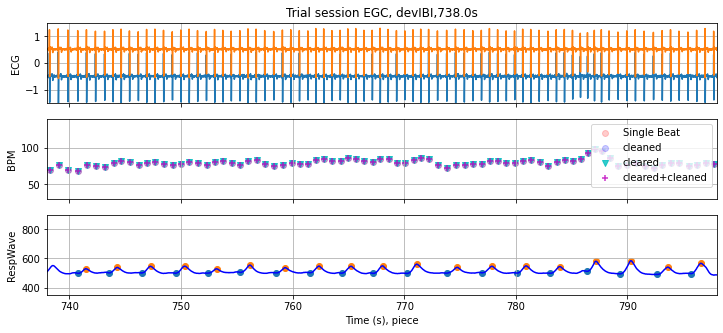

{'Start Time': '2023/04/04 08:45:02', 'Recording': 5, 'Initial Beat Count': 80, 'Cleaned Beat Count': 80, 'Avg HR': 79.5452662280629, 'RMSSD': 36.2390096827274, 'Breath Count': 19, 'Avg BR': 19.860702070537105, 'Avg IE ratio': 0.3903300644201363, 'Seq Var': 1.0750543460948017}


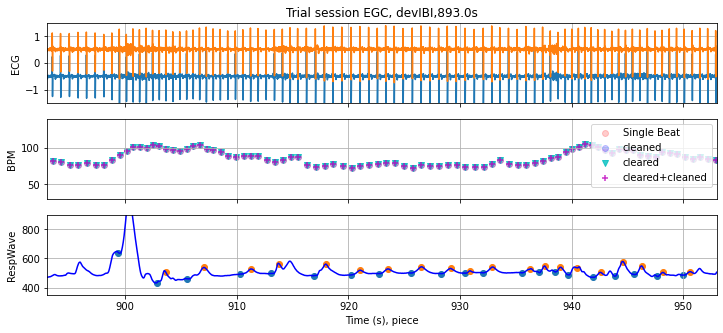

{'Start Time': '2023/04/04 08:47:37', 'Recording': 5, 'Initial Beat Count': 86, 'Cleaned Beat Count': 86, 'Avg HR': 85.8169238956892, 'RMSSD': 28.247227870234294, 'Breath Count': 21, 'Avg BR': 26.52779239335185, 'Avg IE ratio': 0.5059930346206246, 'Seq Var': 1.33617530941071}


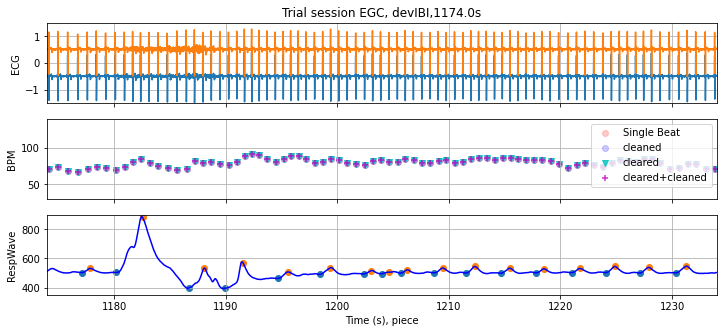

{'Start Time': '2023/04/04 08:52:18', 'Recording': 5, 'Initial Beat Count': 80, 'Cleaned Beat Count': 80, 'Avg HR': 79.39133311280185, 'RMSSD': 37.50510513773298, 'Breath Count': 17, 'Avg BR': 19.796430014918997, 'Avg IE ratio': 0.4149739289425338, 'Seq Var': 1.2700468553705375}


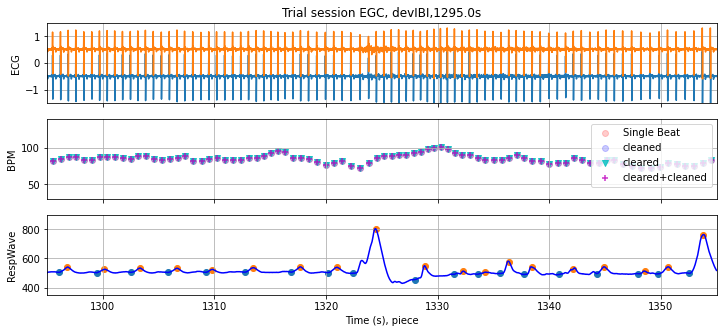

{'Start Time': '2023/04/04 08:54:19', 'Recording': 5, 'Initial Beat Count': 84, 'Cleaned Beat Count': 84, 'Avg HR': 84.51837939361417, 'RMSSD': 27.707595409444934, 'Breath Count': 19, 'Avg BR': 19.88077011744201, 'Avg IE ratio': 0.38607105697140326, 'Seq Var': 1.405332125652185}


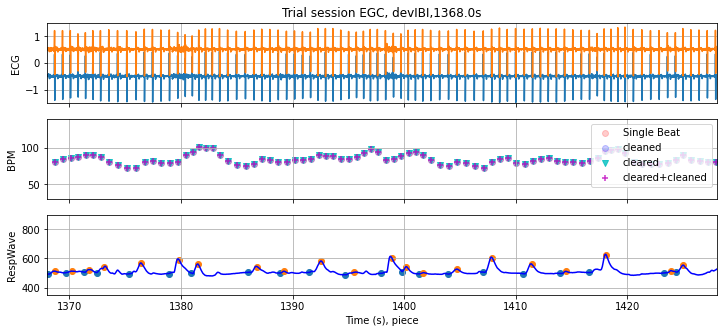

{'Start Time': '2023/04/04 08:55:32', 'Recording': 5, 'Initial Beat Count': 84, 'Cleaned Beat Count': 84, 'Avg HR': 84.10793852110208, 'RMSSD': 37.27753288284145, 'Breath Count': 21, 'Avg BR': 26.280723767550334, 'Avg IE ratio': 0.46388733026090484, 'Seq Var': 1.5970568194952468}


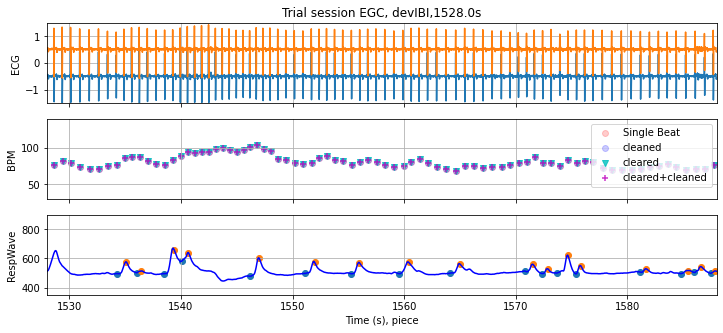

{'Start Time': '2023/04/04 08:58:12', 'Recording': 5, 'Initial Beat Count': 80, 'Cleaned Beat Count': 80, 'Avg HR': 80.24877119069114, 'RMSSD': 37.20759416155712, 'Breath Count': 17, 'Avg BR': 24.402892003828025, 'Avg IE ratio': 0.4957148103911636, 'Seq Var': 1.7573152498255706}


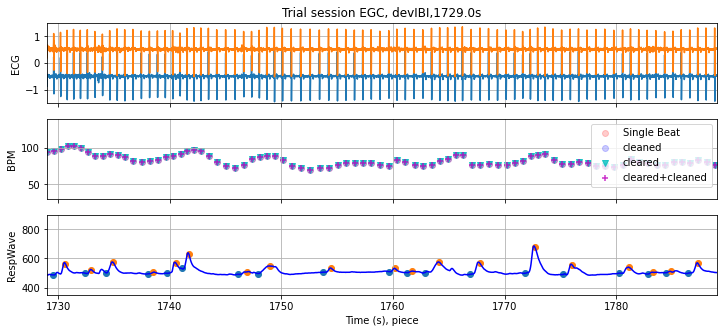

{'Start Time': '2023/04/04 09:01:33', 'Recording': 5, 'Initial Beat Count': 83, 'Cleaned Beat Count': 83, 'Avg HR': 82.38894863098685, 'RMSSD': 35.77487195525141, 'Breath Count': 19, 'Avg BR': 23.939873918596202, 'Avg IE ratio': 0.4170891806393243, 'Seq Var': 1.826556953145314}


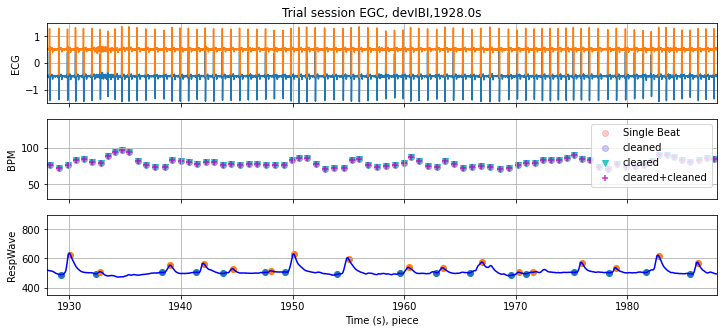

{'Start Time': '2023/04/04 09:04:52', 'Recording': 5, 'Initial Beat Count': 80, 'Cleaned Beat Count': 80, 'Avg HR': 79.63104283486513, 'RMSSD': 41.47273009788663, 'Breath Count': 17, 'Avg BR': 19.40892394189103, 'Avg IE ratio': 0.34268718771732387, 'Seq Var': 1.5886754464580544}


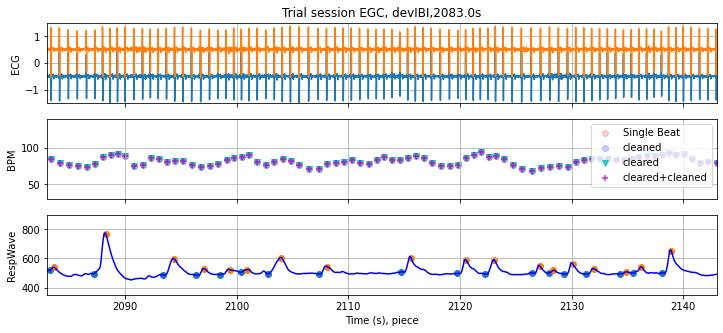

{'Start Time': '2023/04/04 09:07:27', 'Recording': 5, 'Initial Beat Count': 82, 'Cleaned Beat Count': 82, 'Avg HR': 81.63400753289419, 'RMSSD': 39.3654921893356, 'Breath Count': 18, 'Avg BR': 23.22581638615939, 'Avg IE ratio': 0.40996520579168655, 'Seq Var': 1.746856086149702}


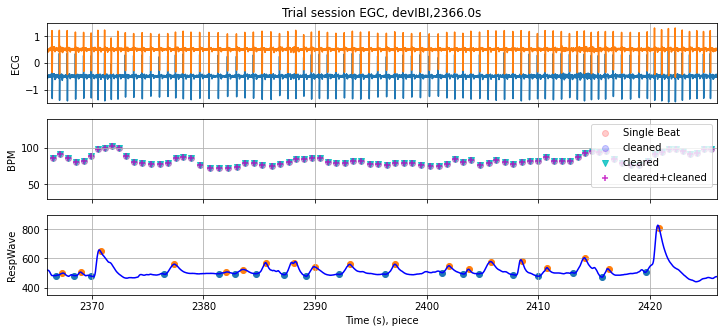

{'Start Time': '2023/04/04 09:12:10', 'Recording': 5, 'Initial Beat Count': 83, 'Cleaned Beat Count': 83, 'Avg HR': 83.5010060362173, 'RMSSD': 33.767497722499726, 'Breath Count': 19, 'Avg BR': 24.0890627433688, 'Avg IE ratio': 0.4514514810965204, 'Seq Var': 1.6288116233215826}


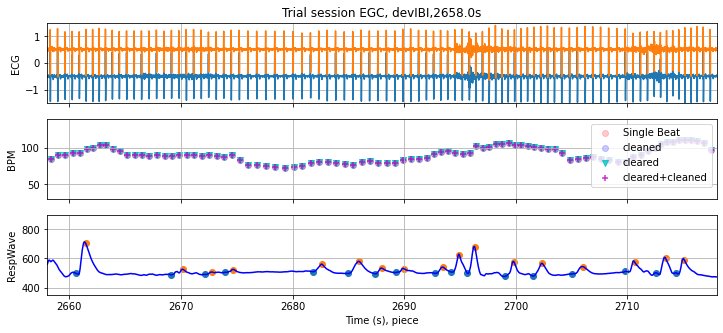

{'Start Time': '2023/04/04 09:17:02', 'Recording': 5, 'Initial Beat Count': 90, 'Cleaned Beat Count': 90, 'Avg HR': 90.29194395211184, 'RMSSD': 23.165986302083375, 'Breath Count': 17, 'Avg BR': 22.506696431018696, 'Avg IE ratio': 0.46242980144400714, 'Seq Var': 1.82456925856582}


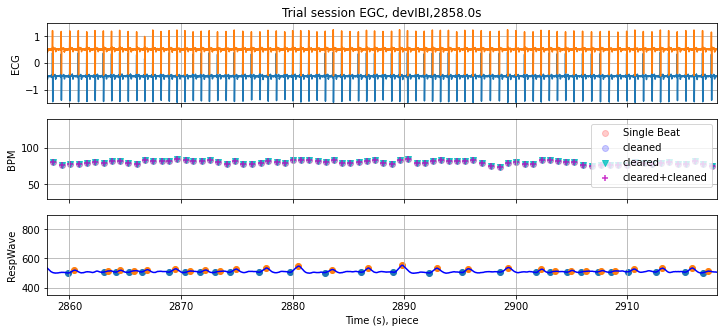

{'Start Time': '2023/04/04 09:20:22', 'Recording': 5, 'Initial Beat Count': 80, 'Cleaned Beat Count': 80, 'Avg HR': 80.34548558802852, 'RMSSD': 22.906524414661725, 'Breath Count': 28, 'Avg BR': 33.93925869621732, 'Avg IE ratio': 0.41144211585501983, 'Seq Var': 1.3033070281183772}


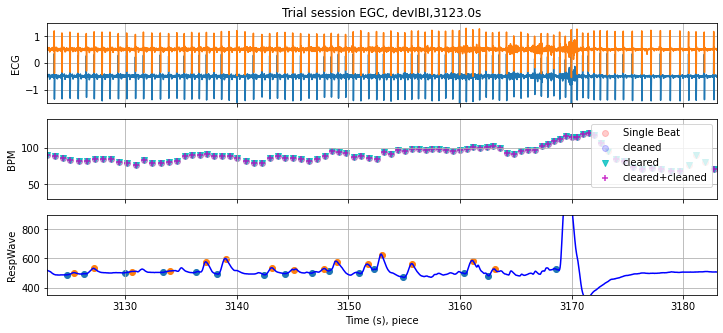

{'Start Time': '2023/04/04 09:24:47', 'Recording': 5, 'Initial Beat Count': 90, 'Cleaned Beat Count': 86, 'Avg HR': 89.6020004167535, 'RMSSD': 24.827494726251025, 'Breath Count': 16, 'Avg BR': 23.542666876772934, 'Avg IE ratio': 0.5658821773950279, 'Seq Var': 1.8636206764632401}


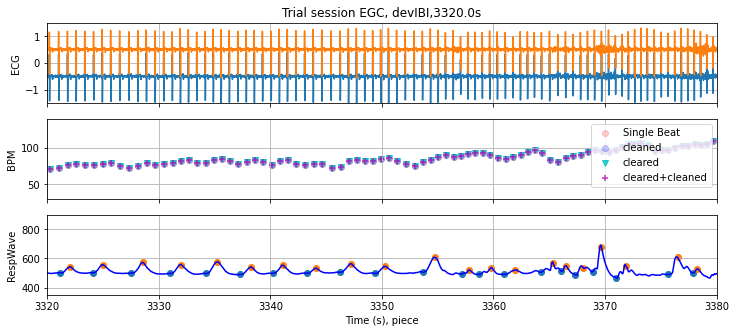

{'Start Time': '2023/04/04 09:28:04', 'Recording': 5, 'Initial Beat Count': 86, 'Cleaned Beat Count': 86, 'Avg HR': 85.63320444097782, 'RMSSD': 27.71642112539063, 'Breath Count': 21, 'Avg BR': 23.245519752574715, 'Avg IE ratio': 0.5204426132310671, 'Seq Var': 1.3804097275192135}


,Start Time,Recording,Initial Beat Count,Cleaned Beat Count,Avg HR,RMSSD,Breath Count,Avg BR,Avg IE ratio,Seq Var
5 2023/04/04 08:32:44,2023/04/04 08:32:44,5,214,0,NaN,-0.0,0,NaN,NaN,NaN
5 2023/04/04 08:35:32,2023/04/04 08:35:32,5,177,0,NaN,-0.0,0,NaN,NaN,NaN
5 2023/04/04 08:39:47,2023/04/04 08:39:47,5,115,113,115.270835,12.296412,0,NaN,NaN,NaN
5 2023/04/04 08:41:22,2023/04/04 08:41:22,5,89,89,88.736748,30.934315,16,23.629879,0.467339,1.835179
5 2023/04/04 08:45:02,2023/04/04 08:45:02,5,80,80,79.545266,36.23901,19,19.860702,0.39033,1.075054
5 2023/04/04 08:47:37,2023/04/04 08:47:37,5,86,86,85.816924,28.247228,21,26.527792,0.505993,1.336175
5 2023/04/04 08:52:18,2023/04/04 08:52:18,5,80,80,79.391333,37.505105,17,19.79643,0.414974,1.270047
5 2023/04/04 08:54:19,2023/04/04 08:54:19,5,84,84,84.518379,27.707595,19,19.88077,0.386071,1.405332
5 2023/04/04 08:55:32,2023/04/04 08:55:32,5,84,84,84.107939,37.277533,21,26.280724,0.463887,1.597057
5 2023/04/04 08:58:12,2023/04/04 08:58:12,5,80,80,80.248771,37.207594,17,24.402892,0.495715,1.757315


In [288]:
t_int =60
sig_ex = 'Trial session'
session_stats = {}
for t in Timing_file.loc[:17,'Times']: #17
    # needs to be corrected when the files have the right correspondence    
    cht = (t-Timing_file.loc[0,'Times']).total_seconds()
    chx = cht+t_int
    
    interval_stats = {}
    interval_stats['Start Time'] = t.strftime('%Y/%m/%d %H:%M:%S')
    interval_stats['Recording'] = recindex
    
    fig, (ax) = plt.subplots(3, 1,figsize = [12,5],sharex = True)
    Ex = C.query('c_sTime>@cht and c_sTime<@chx').copy()
    ax[0].plot(Ex['c_sTime'],Ex[' Lead 1']-0.5)
    ax[0].plot(Ex['c_sTime'],Ex[' Lead 2']+0.5)
    ax[0].set_ylabel('ECG')
    ax[0].set_title(sig_ex +' EGC, devIBI,' + str(cht)+'s')
    ax[0].set_xlim([cht,chx])
    ax[0].set_ylim([-1.5,1.5])
    Ex = V.query('c_sTime>@cht and c_sTime<@chx').copy()
    interval_stats['Initial Beat Count'] = len(Ex)

    ax[1].scatter(x =Ex['c_sTime'],y=(60000/Ex[' Interbeat Interval (MS)']),color='r',alpha = 0.2,label='Single Beat')
    Ex = IBI.query('time>@cht and time<@chx').copy()
    ax[1].scatter(x = Ex.index,y = (60000/Ex['IBI']),color='b',alpha = 0.2,label='cleaned')
    Ex = newV.query('c_sTime>@cht and c_sTime<@chx').copy()
    ax[1].scatter(x =Ex['c_sTime'],y=(60000/Ex[' Interbeat Interval (MS)']),color='c',marker = 'v',alpha = 0.8,label='cleared')
    Ex = newIBI.query('time>@cht and time<@chx').copy()
    interval_stats['Cleaned Beat Count'] =Ex['IBI'].notna().sum()
    ax[1].scatter(x = Ex.index,y = (60000/Ex['IBI']),color='m',marker = '+',alpha = 0.8,label='cleared+cleaned')
    ax[1].legend(loc='upper right')
    ax[1].set_ylabel('BPM')
    ax[1].set_ylim([30,140])
    interval_stats['Avg HR'] = HR_avg(Ex['IBI'])
    interval_stats['RMSSD'] =rmssd(Ex['IBI'])


    Ex = R.query('c_sTime>@cht and c_sTime<@chx').copy()
    ax[2].plot(Ex['c_sTime'],Ex[' Breathing'],color = 'b',label='Respiration')
    Ex = Breaths.query('In>@cht and Ex<@chx').copy()
    ax[2].scatter(Ex['In'],Ex['In_C'])
    ax[2].scatter(Ex['Ex'],Ex['Ex_C'])
    ax[2].set_xlabel('Time (s), piece')
    ax[2].set_ylabel('RespWave')
    ax[2].set_ylim([350,900])

    interval_stats['Breath Count'] = len(Ex)
    interval_stats['Avg BR'] =(60/Ex['Period_T']).mean()
    interval_stats['Avg IE ratio'] =(Ex['IE_Ratio']).mean()
    interval_stats['Seq Var'] =np.power(10,np.log10((Ex['Period_T']/Ex['Period_T'].shift(-1))).abs().mean())
    ax[2].grid()
    ax[1].grid()
    ax[0].grid()
    plt.show()
    print(interval_stats)
    session_stats[' '.join([str(recindex),t.strftime('%Y/%m/%d %H:%M:%S')])] = interval_stats
#     plt.savefig(plot_loc+'_'.join([sig_ex,'Cardio',str(cht)+'s'])+'.png',dpi=mydpi)
    plt.show()
    
Evaluated_Intervals =pd.DataFrame(data=session_stats).transpose()
Evaluated_Intervals 

Dan recommended to check manually a very small sample (5 or 10 intervals) at the start of the process. He also wondered if there was a way to track how many artefacts are detected (to be able to report in the article that f.ex "on average, 2% of beats were detected as artefacts"). With regards to respiration, he thought that respiration rate would be best to use as a control - Finn, this is your area of expertise, so we defer to you there.

In [96]:
V

,DateTime,Interbeat Interval (MS)
0,2024-04-02 11:54:17.804,0
1,2024-04-02 11:54:18.000,195
2,2024-04-02 11:54:18.195,195
3,2024-04-02 11:54:18.390,195
4,2024-04-02 11:54:18.585,195
...,...,...
7209,2024-04-02 13:09:52.855,1734
7210,2024-04-02 13:09:53.167,339
7211,2024-04-02 13:09:54.378,1203
7212,2024-04-02 13:09:55.863,1492


<Axes: xlabel='DateTime'>

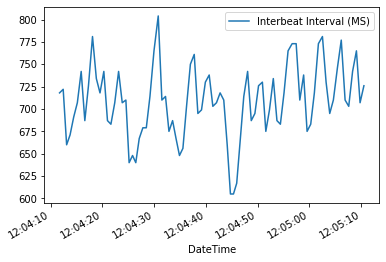

In [124]:
A = qex.cut_by_time(eqfiles.loc[recindex,'RRloc'],t1,t2)
A.plot()

In [108]:
np.sqrt(A['Interbeat Interval (MS)'].diff().pow(2).sum()/(len(A)-1))

36.734147470187

In [112]:
rmssd(A['Interbeat Interval (MS)'])

36.734147470187

In [119]:
HR_avg(A['Interbeat Interval (MS)'])

84.73009095035556

Index([   0.0,  0.039,  0.078,  0.117,  0.156,  0.195,  0.234,  0.273,  0.312,
        0.351,
       ...
       59.609, 59.648, 59.687, 59.726, 59.766, 59.805, 59.844, 59.883, 59.922,
       59.961],
      dtype='float64', name='DateTime', length=1536)

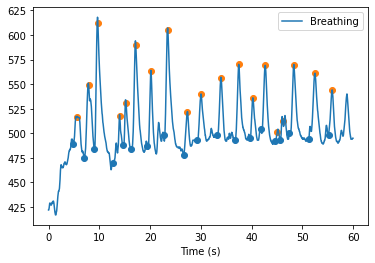

,Breathing
Time (s),
0.000,422
0.039,422
0.078,423
0.117,424
0.156,426
...,...
59.805,494
59.844,494
59.883,495


In [145]:
B = qex.cut_by_time(eqfiles.loc[recindex,'RESPloc'],t1,t2)
B.loc[:,'Time (s)']  = (B.index-B.index[0]).total_seconds()
B.set_index('Time (s)',drop=True,inplace=True)
Breaths = rp2.breath_cycles(rp2.EQ_Inspiration_Extract(B.loc[:,'Breathing']),B.loc[:,'Breathing'])
B.plot()
plt.scatter(Breaths['In'],Breaths['In_C'])
plt.scatter(Breaths['Ex'],Breaths['Ex_C'])
plt.show()
B

In [143]:
Breaths 

,In,Ex,In_C,Ex_C,IDepth,EDepth,Insp_T,Period_T,Exp_T,IE_Ratio,IE_DR,Insp_V,Exp_V,RelID,RelED
0,4.883,5.586,489,517,28,42.0,0.703,2.148,1.445,0.486505,0.666667,39.829303,29.065744,NaN,NaN
1,7.031,7.891,475,549,74,65.0,0.860,1.953,1.093,0.786825,1.138462,86.046512,59.469350,NaN,NaN
2,8.984,9.726,484,612,128,142.0,0.742,3.789,3.047,0.243518,0.901408,172.506739,46.603216,2.666667,3.021277
3,12.773,14.023,470,518,48,30.0,1.250,1.914,0.664,1.882530,1.600000,38.400000,45.180723,0.648649,0.461538
4,14.687,15.273,488,531,43,47.0,0.586,1.641,1.055,0.555450,0.914894,73.378840,44.549763,0.565789,0.723077
5,16.328,17.187,484,590,106,103.0,0.859,3.164,2.305,0.372668,1.029126,123.399302,44.685466,1.394737,1.584615
6,19.492,20.195,487,563,76,65.0,0.703,3.164,2.461,0.285656,1.169231,108.108108,26.412028,1.000000,1.000000
7,22.656,23.516,498,605,107,127.0,0.860,3.945,3.085,0.278768,0.842520,124.418605,41.166937,1.407895,1.953846
8,26.601,27.344,478,522,44,29.0,0.743,2.657,1.914,0.388192,1.517241,59.219381,15.151515,0.758621,0.460317
9,29.258,30.039,493,540,47,42.0,0.781,3.945,3.164,0.246839,1.119048,60.179257,13.274336,0.810345,0.666667


In [141]:
Breaths = rp2.EQ_Inspiration_Extract(B.loc[:,'Breathing'])

,In,Ex,In_C,Ex_C,IDepth,EDepth,Insp_T,Period_T,Exp_T,IE_Ratio,IE_DR,Insp_V,Exp_V,RelID,RelED
0,4.883,5.586,-10.813107,13.774090,24.587197,41.151948,0.703,2.148,1.445,0.486505,0.597473,34.974675,28.478857,NaN,NaN
1,7.031,7.891,-27.377858,40.309614,67.687472,54.736862,0.860,1.953,1.093,0.786825,1.236598,78.706363,50.079471,NaN,NaN
2,8.984,9.726,-14.427248,96.631381,111.058629,129.818377,0.742,3.789,3.047,0.243518,0.855492,149.674702,42.605309,3.056417,3.141222
3,12.773,14.023,-33.186996,3.149218,36.336214,16.004553,1.250,1.914,0.664,1.882530,2.270367,29.068971,24.103242,0.536823,0.292391
4,14.687,15.273,-12.855335,20.202762,33.058097,41.327344,0.586,1.641,1.055,0.555450,0.799909,56.413135,39.172838,0.549361,0.773764
5,16.328,17.187,-21.124582,75.307690,96.432272,91.130321,0.859,3.164,2.305,0.372668,1.058180,112.261085,39.535931,1.602517,1.706216
6,19.492,20.195,-15.822631,44.352860,60.175491,53.410788,0.703,3.164,2.461,0.285656,1.126654,85.598138,21.702880,1.000000,1.000000
7,22.656,23.516,-9.057928,89.431767,98.489695,112.381692,0.860,3.945,3.085,0.278768,0.876386,114.522901,36.428425,1.636708,2.104101
8,26.601,27.344,-22.949925,12.233660,35.183584,23.430212,0.743,2.657,1.914,0.388192,1.501633,47.353411,12.241490,0.704479,0.438679
9,29.258,30.039,-11.196552,30.384748,41.581300,35.898576,0.781,3.945,3.164,0.246839,1.158299,53.241101,11.345947,0.832580,0.647236
